# **SOLUCIÓN DE KLEIN-GORDON HOMOGENEO A PARTIR DE ABUPINN**

En este proyecto nos centramos en la solución de la EDP:

$$ \partial_{tt} \phi(x,t) - \nabla^2 \phi(x,t) + \left(\frac{mc}{\hbar}\right)^2 \phi(x,t) = 0 $$

Con condiciones iniciales de posición:

$$ \psi(x,0) = \sum_{k = \{1,2,5\}} A e^{ix \cdot k} e^{\frac{-x^2}{2\sigma}} $$

Bajo una arquitectura fully-connected con combinación de activación. Las compuertas de activación se usó softmax ($G(\alpha_i)$):

$$ \sigma(x) = G(\alpha_1)\bigg(\frac{1}{1+x^2}\bigg) + G(\alpha_2)\sin(\omega_0 x) + G(\alpha_3) \tanh(x) $$

Se usaron 5 capas internas, cada una con 50 neuronas. Para la optimización se uso AdamW y un Anzats:

$$ C(\theta) = \phi(x,0) \cos(\omega t) + \frac{\pi(x,0)}{\omega}\sin(\omega t) + \mathcal{N}_{\theta}(x,t) \sin^2(\omega t)  $$



## **1. Librerías usadas**

In [ ]:
#Starndard libreries
import os
import sys
import io
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

#import libreries of NN
import tensorflow as tf
from tensorflow import keras

import tensorflow as tf
tf.keras.backend.set_floatx('float64') # Fuerza todo a 64 bits globalmente

#import optimization
from scipy.optimize import minimize
from scipy.interpolate import CubicSpline
import scipy.optimize


In [ ]:
# Define la ruta
path = '/content/ABUN_PINN'

# Crea la carpeta si no existe
if not os.path.exists(path):
    os.makedirs(path)
    print(f"Carpeta '{path}' creada con éxito.")
else:
    print(f"La carpeta '{path}' ya existe.")

La carpeta '/content/ABUN_PINN' ya existe.


## **2. Entrenamiento del la PINN**

In [ ]:
# Configurar semilla
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

# Parámetros físicos
sigma = 1.0
k0_sim = [1.0, 2.0, 5.0]
A_sim = [1.0, 1.0, 1.0]
k_boost = 0.0
m = 1.0
c = 1.0


#Parámetros iniciales
N = 4096
L = 80 * sigma
dx = L / N
T = L/2 - 4*sigma
dt = T / N

X_min, X_max = -L/2, L/2
T_min, T_max = 0.0, T

def condition_initial(x, sigma, k0, k_boost, m, A, dx):
    k0_arr = np.array(k0).reshape(-1, 1)
    A_arr = np.array(A).reshape(-1, 1)
    x_arr = x.reshape(1, -1)

    fase_estacionaria = np.sum(A_arr * np.exp(1j * k0_arr * x_arr) + A_arr * np.exp(-1j * k0_arr * x_arr), axis=0)
    fase_estacionaria = fase_estacionaria.reshape(-1, 1)

    psi_static = np.exp(-(x**2)/(2 * sigma**2)) * fase_estacionaria
    psi_moving = psi_static * np.exp(1j * k_boost * x)
    psi_moving = psi_moving / np.sqrt(np.max(np.abs(psi_moving)**2))

    phi0 = psi_moving.real
    phi0 = phi0 / np.sqrt(np.max(np.abs(phi0)**2))

    phi_k = np.fft.fft(psi_moving.flatten())
    k_freqs = 2 * np.pi * np.fft.fftfreq(len(x), d=dx)
    omega_k = np.sqrt(k_freqs**2 + m**2)

    pi_k_calc = -1j * omega_k * phi_k
    pi0 = np.fft.ifft(pi_k_calc).real.reshape(-1, 1)

    return phi0, pi0

In [ ]:
x_grid = np.linspace(X_min, X_max, 4000).reshape(-1, 1)
phi0_vals, pi0_vals = condition_initial(x_grid, sigma, k0_sim, k_boost, m, A_sim, dx)
interp_phi0 = CubicSpline(x_grid.flatten(), phi0_vals.flatten(), extrapolate=True)
interp_pi0  = CubicSpline(x_grid.flatten(), pi0_vals.flatten(), extrapolate=True)

In [ ]:
class SirenInitializer(tf.keras.initializers.Initializer):
    def __init__(self, is_first_layer=False, omega0=1.0, seed=None):
        self.is_first_layer = is_first_layer
        self.omega0 = float(omega0)
        self.seed = seed

    def __call__(self, shape, dtype=None, **kwargs):
        fan_in = shape[0]
        if self.is_first_layer:
            limit = 1.0 / fan_in
        else:
            limit = np.sqrt(6.0 / fan_in) / self.omega0

        # Corrección clave
        target_dtype = dtype if dtype is not None else tf.float64
        limit = tf.cast(limit, target_dtype)

        return tf.random.uniform(shape, minval=-limit, maxval=limit, dtype=target_dtype, seed=self.seed)

In [ ]:
class AbuLayer(tf.keras.layers.Layer):
    def __init__(self, units, is_first_layer=False, omega0=1.0, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.is_first_layer = is_first_layer
        self.omega0 = tf.constant(omega0, dtype=tf.float64)

    def build(self, input_shape):
        siren_init = SirenInitializer(is_first_layer=self.is_first_layer, omega0=self.omega0, seed=seed)
        glorot_init = tf.keras.initializers.GlorotNormal(seed=seed)

        self.dense_sin = tf.keras.layers.Dense(self.units, dtype=tf.float32, kernel_initializer=siren_init)
        self.dense_tanh = tf.keras.layers.Dense(self.units, dtype=tf.float32, kernel_initializer=glorot_init)
        self.dense_rat = tf.keras.layers.Dense(self.units, dtype=tf.float32, kernel_initializer=glorot_init)
        self.coeff = self.add_weight(shape=(3,), initializer=tf.keras.initializers.Constant(1.0/3.0), trainable=True, name="act_coeff")

    def call(self, inputs):
        z_sin = tf.cast(self.dense_sin(inputs), tf.float64)
        z_tanh = tf.cast(self.dense_tanh(inputs), tf.float64)
        z_rat = tf.cast(self.dense_rat(inputs), tf.float64)

        a_sin = tf.math.sin(tf.cast(self.omega0, tf.float64) * z_sin)
        a_tanh = tf.math.tanh(z_tanh)
        a_rat = tf.math.reciprocal(1.0 + tf.math.square(z_rat))

        w = tf.nn.softmax(tf.cast(self.coeff, tf.float64))
        return w[0]*a_sin + w[1]*a_tanh + w[2]*a_rat

In [ ]:
@tf.keras.utils.register_keras_serializable()
class AbuPINN_Ansatz(tf.keras.Model):
    def __init__(self, num_layers=5, hidden_dim=50, L=80.0, T_max=40.0, X_min=-40.0, X_max=40.0, omega=1.0, omega0=15.0, **kwargs):
        super().__init__(**kwargs)
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        self.L = L
        self.T_max = tf.constant(T_max, dtype=tf.float32)
        self.X_min = tf.constant(X_min, dtype=tf.float32)
        self.X_max = tf.constant(X_max, dtype=tf.float32)
        self.omega = tf.constant(omega, dtype=tf.float64) # Asignación explícita
        self.omega0 = tf.constant(omega0, dtype=tf.float64)

    def build(self, input_shape):
        self.hidden_layers = []
        for i in range(self.num_layers):
            is_first = (i == 0)
            self.hidden_layers.append(
                AbuLayer(self.hidden_dim, is_first_layer=is_first, omega0=self.omega0, name=f"AbuLayer_{i}")
            )
        self.out_layer = tf.keras.layers.Dense(1, dtype=tf.float64, kernel_initializer='glorot_uniform', name="Output")
        super().build(input_shape)

    def call(self, inputs):
        x = tf.cast(inputs[0], tf.float64)
        t = tf.cast(inputs[1], tf.float64)
        phi0 = tf.cast(inputs[2], tf.float64)
        pi0 = tf.cast(inputs[3], tf.float64)

        # Normalización
        x_norm = 2.0 * (x - tf.cast(self.X_min, tf.float64)) / (tf.cast(self.X_max, tf.float64) - tf.cast(self.X_min, tf.float64)) - 1.0
        t_norm = t / tf.cast(self.T_max, tf.float64)

        h = tf.concat([x_norm, t_norm], axis=-1)
        for layer in self.hidden_layers:
            h = layer(h)
        N_xt = self.out_layer(h)

        # Ansatz Multiplicativo
        phi_pred = phi0 * tf.math.cos(self.omega * t) + \
                   (pi0 / self.omega) * tf.math.sin(self.omega * t) + \
                   (1.0 - tf.math.cos(self.omega * t)) * N_xt
        return phi_pred

In [ ]:
def stochastic_resampling(n_phys_points):
    x_f = np.random.uniform(X_min, X_max, (n_phys_points, 1)).astype(np.float32)
    t_f = np.random.uniform(T_min, T_max, (n_phys_points, 1)).astype(np.float32)

    phi0_f = interp_phi0(x_f).reshape(-1, 1).astype(np.float64)
    pi0_f = interp_pi0(x_f).reshape(-1, 1).astype(np.float64)

    return (
        tf.convert_to_tensor(x_f),
        tf.convert_to_tensor(t_f),
        tf.convert_to_tensor(phi0_f),
        tf.convert_to_tensor(pi0_f)
    )

In [ ]:
def pde_loss(model, x_f, t_f, phi0_f, pi0_f, c_val, m_val):
    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch([x_f, t_f])
        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch([x_f, t_f])
            phi = model([x_f, t_f, phi0_f, pi0_f])
        phi_x = tape1.gradient(phi, x_f)
        phi_t = tape1.gradient(phi, t_f)

    phi_xx = tape2.gradient(phi_x, x_f)
    phi_tt = tape2.gradient(phi_t, t_f)
    del tape1, tape2

    c_tf = tf.cast(c_val, tf.float64)
    m_tf = tf.cast(m_val, tf.float64)
    phi = tf.cast(phi, tf.float64)
    phi_xx = tf.cast(phi_xx, tf.float64)
    phi_tt = tf.cast(phi_tt, tf.float64)
    t_f_64 = tf.cast(t_f, tf.float64)

    # Residuo de Klein-Gordon
    residual = phi_tt - tf.square(c_tf) * phi_xx + tf.square(m_tf) * phi

    # Pesos temporales en float64
    t_weights = 1.0 + 10.0 * t_f_64

    return tf.reduce_mean(t_weights * tf.square(residual))

In [ ]:
class GradientAccumulator:
    def __init__(self, trainable_variables, accum_steps):
        self.accum_steps = accum_steps
        self.step_counter = tf.Variable(0, dtype=tf.int32, trainable=False)
        self.accumulated_grads = [tf.Variable(tf.zeros_like(v, dtype=tf.float64), trainable=False) for v in trainable_variables]

    def reset(self):
        for acc_grad in self.accumulated_grads:
            acc_grad.assign(tf.zeros_like(acc_grad))

    def apply(self, optimizer, grads, trainable_variables):
        for acc_grad, grad in zip(self.accumulated_grads, grads):
            if grad is not None:
                grad_64 = tf.cast(grad, tf.float64)
                acc_grad.assign_add(grad_64 / tf.cast(self.accum_steps, tf.float64))

        self.step_counter.assign_add(1)

        def apply_gradients():
            clipped_grads, _ = tf.clip_by_global_norm(self.accumulated_grads, 1.0)
            optimizer.apply_gradients(zip(clipped_grads, trainable_variables))
            self.reset()
            return tf.constant(True)

        tf.cond(tf.equal(self.step_counter % self.accum_steps, 0), apply_gradients, lambda: tf.constant(False))

In [ ]:
@tf.function(jit_compile=False, reduce_retracing=True)
def train_step(model, optimizer, accumulator, x_f, t_f, phi0_f, pi0_f, c_tf, m_tf):
    with tf.GradientTape() as tape:
        lf = pde_loss(model, x_f, t_f, phi0_f, pi0_f, c_tf, m_tf)
        reg_terms = [tf.reduce_mean(tf.square(tf.cast(v, tf.float64))) for v in model.trainable_variables]
        reg_loss = 0.01 * tf.reduce_mean(tf.stack(reg_terms))
        loss_total = 100.0 * lf + reg_loss

    grads = tape.gradient(loss_total, model.trainable_variables)
    accumulator.apply(optimizer, grads, model.trainable_variables)
    return lf

In [ ]:
@tf.function(jit_compile=False, reduce_retracing=True)
def get_loss_and_grads_lbfgs(x_f, t_f, phi0_f, pi0_f, c_tf, m_tf):
    with tf.GradientTape() as tape:
        loss = pde_loss(model, x_f, t_f, phi0_f, pi0_f, c_tf, m_tf)
    grads = tape.gradient(loss, model.trainable_variables)

    flat_grads = tf.concat([tf.reshape(g, [-1]) for g in grads if g is not None], axis=0)
    return loss, flat_grads

def set_flat_weights(model, flat_weights):

    flat_weights = tf.cast(flat_weights, tf.float64)
    start = 0
    for w in model.trainable_variables:
        shape = w.shape
        size = tf.reduce_prod(shape)

        new_w = tf.reshape(flat_weights[start:start+size], shape)
        w.assign(tf.cast(new_w, w.dtype))
        start += size

def get_flat_weights(model):
    weights = [tf.reshape(tf.cast(w, tf.float64), [-1]) for w in model.trainable_variables]
    return tf.concat(weights, axis=0).numpy()

def lbfgs_objective(flat_weights, x_f, t_f, phi0_f, pi0_f, c_tf, m_tf):
    set_flat_weights(model, flat_weights)
    loss, grads = get_loss_and_grads_lbfgs(x_f, t_f, phi0_f, pi0_f, c_tf, m_tf)

    loss_val = loss.numpy().astype(np.float64)
    grads_val = grads.numpy().astype(np.float64)

    global lbfgs_iter
    lbfgs_iter += 1
    if lbfgs_iter % 100 == 0:
        print(f"L-BFGS Iter {lbfgs_iter} | PDE Loss={loss_val:.2e}")
        loss_history["epoch"].append(epochs_adam + lbfgs_iter)
        loss_history["pde"].append(loss_val)

    return loss_val, grads_val

In [ ]:
neurons = 50
num_blocks = 5
epochs_adam = 20000     # Fase de exploración de AdamW
max_iter_lbfgs = 10000  # Fase de refinamiento L-BFGS
print_every = 1000
as_freq = 1000
stop_resampling = 15000
n_phys = N

# modelo
model = AbuPINN_Ansatz(
    num_layers=num_blocks,
    hidden_dim=neurons,
    L=L,
    T_max=T,
    omega0=20.0
)

# Inicialización forzada
x_dummy, t_dummy, phi0_d, pi0_d = stochastic_resampling(1)
_ = model([x_dummy, t_dummy, phi0_d, pi0_d])

# Learning Rate
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=5e-4, decay_steps=1000, decay_rate=0.85
)
optimizer = tf.keras.optimizers.AdamW(learning_rate=lr_schedule)
optimizer.build(model.trainable_variables)

accumulator = GradientAccumulator(model.trainable_variables, accum_steps=2)
loss_history = {"epoch": [], "pde": []}

c_tf = tf.cast(c, tf.float64)
m_tf = tf.cast(m, tf.float64)

# Muestreo inicial
x_f_dyn, t_f_dyn, phi0_dyn, pi0_dyn = stochastic_resampling(n_phys)

start_time = time.time()

print(" FASE 1: Exploración Global con AdamW")
for epoch in range(1, epochs_adam + 1):

    # Detenemos el resampling
    if epoch % as_freq == 0 and epoch <= stop_resampling:
        x_f_dyn, t_f_dyn, phi0_dyn, pi0_dyn = stochastic_resampling(n_phys)

    lf_val = train_step(model, optimizer, accumulator, x_f_dyn, t_f_dyn, phi0_dyn, pi0_dyn, c_tf, m_tf)

    loss_history["epoch"].append(epoch)
    loss_history["pde"].append(lf_val.numpy())

    if epoch % print_every == 0 or epoch == 1:
        elapsed = time.time() - start_time
        print(f"AdamW Ep {epoch}/{epochs_adam} | PDE Loss={lf_val:.2e} | LR={lr_schedule(optimizer.iterations):.2e} | Time: {elapsed:.1f}s")


print(" FASE 2: Refinamiento Fino con L-BFGS")
lbfgs_iter = 0
initial_weights = get_flat_weights(model)

# Lanzar L-BFGS sobre la malla estática final
results = scipy.optimize.minimize(
    fun=lbfgs_objective,
    x0=initial_weights,
    args=(x_f_dyn, t_f_dyn, phi0_dyn, pi0_dyn, c_tf, m_tf),
    method='L-BFGS-B',
    jac=True,
    options={
        'maxiter': max_iter_lbfgs,
        'maxfun': max_iter_lbfgs * 2,
        'ftol': 1.0 * np.finfo(float).eps, # Tolerancia máxima de la máquina
        'gtol': 1e-15
    }
)

# Establecer los mejores pesos encontrados
set_flat_weights(model, tf.convert_to_tensor(results.x, dtype=tf.float32))
print(f"\nL-BFGS Finalizado: {results.message}")
print(f"Pérdida final alcanzada: {results.fun:.2e}")

# GUARDADO FINAL
df_loss = pd.DataFrame(loss_history)
df_loss.to_csv(f"{path}/training_loss_history_AbuPINN_{neurons}.csv", index=False)
model.save_weights(f"{path}/AbuPINN_ultimate_{neurons}.weights.h5")
print("\nEntrenamiento finalizado exitosamente.")

 FASE 1: Exploración Global con AdamW
AdamW Ep 1/20000 | PDE Loss=5.08e+01 | LR=5.00e-04 | Time: 7.2s
AdamW Ep 1000/20000 | PDE Loss=3.07e-03 | LR=4.61e-04 | Time: 57.5s
AdamW Ep 2000/20000 | PDE Loss=8.27e-02 | LR=4.25e-04 | Time: 108.7s
AdamW Ep 3000/20000 | PDE Loss=3.51e-04 | LR=3.92e-04 | Time: 158.9s
AdamW Ep 4000/20000 | PDE Loss=1.27e-02 | LR=3.61e-04 | Time: 209.2s
AdamW Ep 5000/20000 | PDE Loss=1.48e-02 | LR=3.33e-04 | Time: 259.4s
AdamW Ep 6000/20000 | PDE Loss=8.49e-04 | LR=3.07e-04 | Time: 309.7s
AdamW Ep 7000/20000 | PDE Loss=2.36e-03 | LR=2.83e-04 | Time: 360.1s
AdamW Ep 8000/20000 | PDE Loss=7.79e-03 | LR=2.61e-04 | Time: 410.3s
AdamW Ep 9000/20000 | PDE Loss=1.70e-04 | LR=2.41e-04 | Time: 460.6s
AdamW Ep 10000/20000 | PDE Loss=4.58e-06 | LR=2.22e-04 | Time: 510.8s
AdamW Ep 11000/20000 | PDE Loss=5.91e-03 | LR=2.05e-04 | Time: 561.1s
AdamW Ep 12000/20000 | PDE Loss=3.25e-03 | LR=1.89e-04 | Time: 611.4s
AdamW Ep 13000/20000 | PDE Loss=9.30e-03 | LR=1.74e-04 | Time: 661.7

TypeError: in user code:

    File "/tmp/ipykernel_33036/373156798.py", line 8, in get_loss_and_grads_lbfgs  *
        flat_grads = tf.concat([tf.reshape(g, [-1]) for g in grads if g is not None], axis=0)

    TypeError: Tensors in list passed to 'values' of 'ConcatV2' Op have types [float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float32, float64, float64] that don't all match.


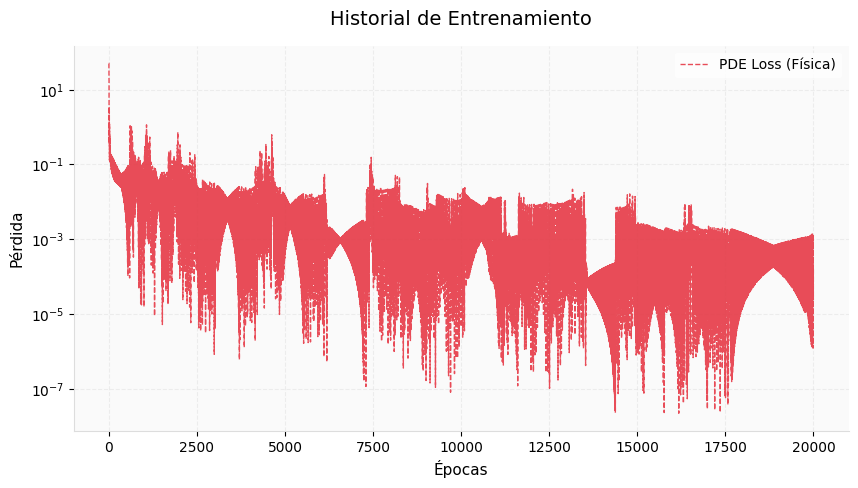

In [ ]:
import matplotlib.pyplot as plt

# Gráfica de Convergencia
plt.figure(figsize=(10, 5))

# Paleta de tonos pastel enfocada en aqua, verdes y azules
color_pde    = "#E63946" # Rojo carmesí vibrante

plt.semilogy(loss_history["epoch"], loss_history["pde"], color=color_pde, label="PDE Loss (Física)", linestyle="--", alpha=0.9, linewidth=1)
plt.title("Historial de Entrenamiento", fontsize=14, pad=15)
plt.xlabel("Épocas", fontsize=11)
plt.ylabel("Pérdida", fontsize=11)

# Estilizar la leyenda para que se vea más limpia
plt.legend(frameon=True, facecolor='#ffffff', edgecolor='none', fontsize=10)

# Suavizar la cuadrícula y darle un fondo sutil a los ejes para resaltar los pasteles
plt.grid(True, which="both", ls="--", alpha=0.5, color='#E0E0E0')
plt.gca().set_facecolor('#FAFAFA')

# Quitar los bordes superior y derecho para un look más moderno
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#DDDDDD')
plt.gca().spines['bottom'].set_color('#DDDDDD')

plt.show()

In [ ]:
neurons = 50
# Nombre correcto basado en tu captura de archivos: AbuPINN (sin 'n' extra)
nombre_archivo = f"AbuPINN_ultimate_{neurons}.weights.h5"
ruta_completa = os.path.join("/content/ABUN_PINN", nombre_archivo)

if os.path.exists(ruta_completa):
    try:
        model.load_weights(ruta_completa)
        print(f"   -> ¡ÉXITO! Pesos cargados desde: {nombre_archivo}")
    except Exception as e:
        print(f"\n[ERROR CRÍTICO]: El archivo existe pero no pudo ser leído: {e}")
else:
    print(f"\n[ERROR]: El archivo '{nombre_archivo}' NO existe en /content/ABUN_PINN/")
    print("Archivos encontrados en la carpeta:")
    print(os.listdir("/content/ABUN_PINN/"))
    # No uses sys.exit() aquí si quieres continuar con pesos aleatorios
    print("   -> Procediendo con inicialización aleatoria.")

   -> ¡ÉXITO! Pesos cargados desde: AbuPINN_ultimate_50.weights.h5


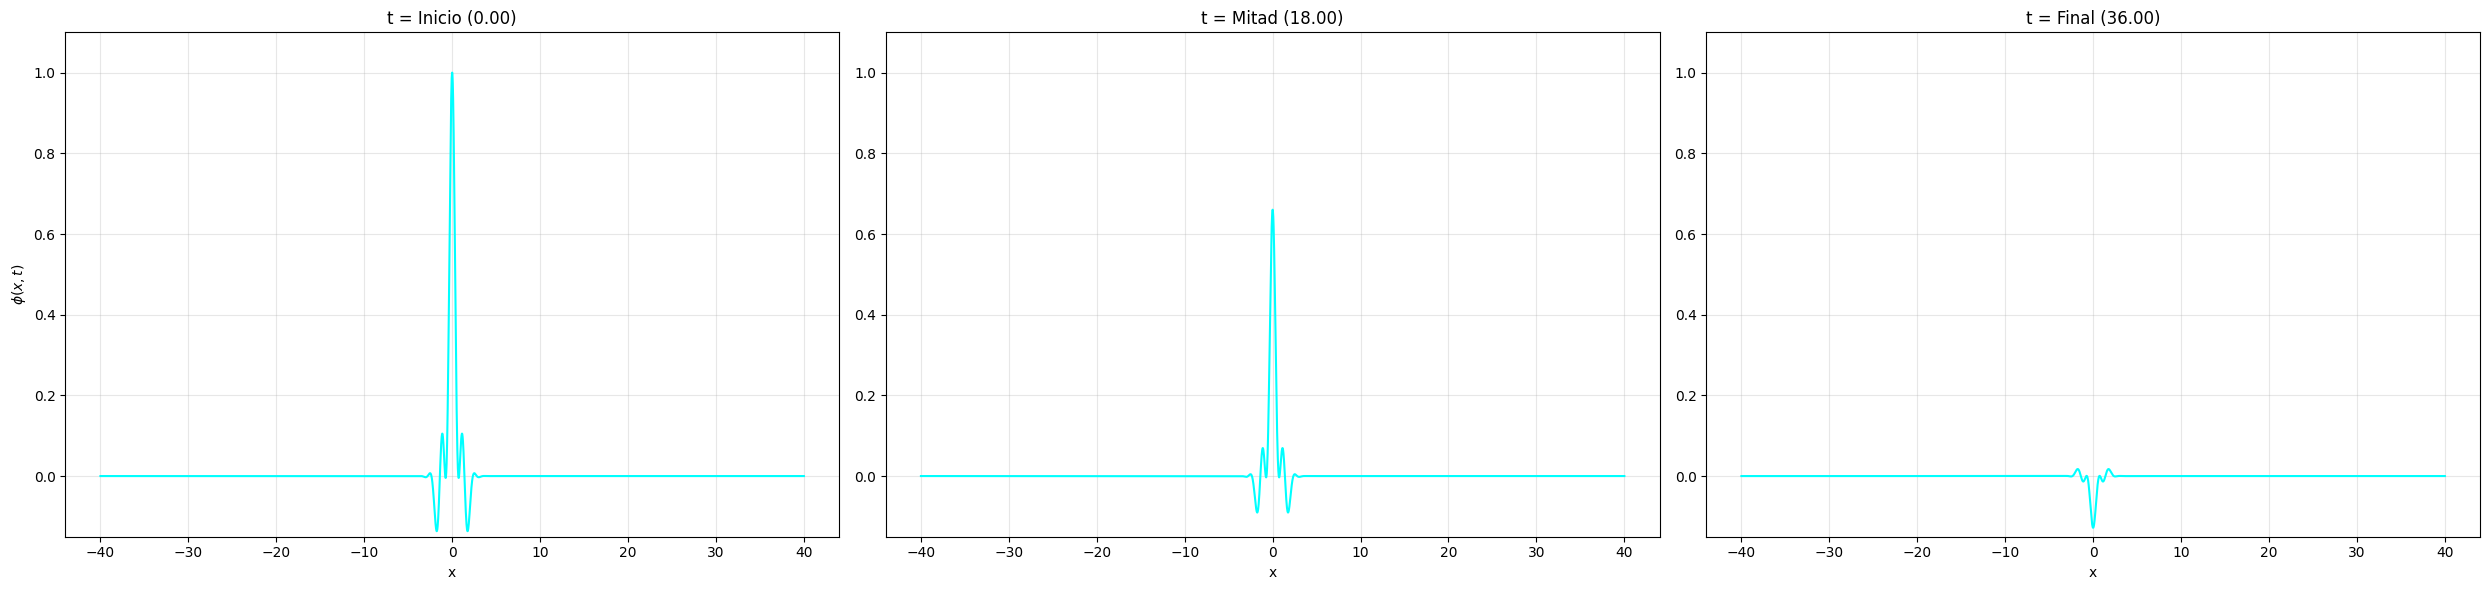

Amplitud máxima en t=Inicio: 1.0000
Amplitud máxima en t=Mitad:  0.6602
Amplitud máxima en t=Final:  0.0174


In [ ]:
# 1. Definir la malla espacial física (x_grid original)
x_test_1d = x_grid.flatten().astype(np.float32)

t_0_val = 0.0
t_mid_val = T / 2.0
t_end_val = T

# 2. EVALUAR LAS CONDICIONES INICIALES FÍSICAS EN CADA PUNTO DE X
# ESTO ES LO QUE LE DA LA VIDA AL HARD-CONSTRAINT
phi0_real = interp_phi0(x_test_1d).reshape(-1, 1).astype(np.float32)
pi0_real = interp_pi0(x_test_1d).reshape(-1, 1).astype(np.float32)

# 3. Crear los tensores de entrada para cada instante de tiempo
# El modelo espera [x, t, phi0, pi0]
def prepare_input(x_1d, t_val, phi0, pi0):
    t_1d = np.full_like(x_1d, t_val).reshape(-1, 1).astype(np.float32)
    return [x_1d.reshape(-1, 1), t_1d, phi0, pi0]

# 4. Predicción usando el Ansatz (phi = phi0 + t*pi0 + t^2*N)
u_0 = model.predict(prepare_input(x_test_1d, 0.0, phi0_real, pi0_real), verbose=0)
u_mid = model.predict(prepare_input(x_test_1d, T/2, phi0_real, pi0_real), verbose=0)
u_end = model.predict(prepare_input(x_test_1d, T, phi0_real, pi0_real), verbose=0)

# 5. Graficar
fig, axs = plt.subplots(1, 3, figsize=(25, 6))

axs[0].plot(x_test_1d, u_0.flatten(), color='aqua', linewidth=1.5)
axs[0].set_title(f"t = Inicio ({t_0_val:.2f})")
axs[0].set_xlabel("x")
axs[0].set_ylabel(r"$\phi(x,t)$")
axs[0].grid(True, alpha=0.3)

axs[1].plot(x_test_1d, u_mid.flatten(), color='aqua', linewidth=1.5)
axs[1].set_title(f"t = Mitad ({t_mid_val:.2f})")
axs[1].set_xlabel("x")
axs[1].grid(True, alpha=0.3)

axs[2].plot(x_test_1d, u_end.flatten(), color='aqua', linewidth=1.5)
axs[2].set_title(f"t = Final ({t_end_val:.2f})")
axs[2].set_xlabel("x")
axs[2].grid(True, alpha=0.3)

# Asegurar que todos los ejes Y tengan la misma escala visual para comparar amplitud
y_min = np.min([u_0, u_mid, u_end]) * 1.1
y_max = np.max([u_0, u_mid, u_end]) * 1.1
for ax in axs:
    ax.set_ylim([y_min, y_max])

plt.tight_layout()
plt.show()

# Verificación de la conservación de energía (Amplitud)
print(f"Amplitud máxima en t=Inicio: {np.max(u_0):.4f}")
print(f"Amplitud máxima en t=Mitad:  {np.max(u_mid):.4f}")
print(f"Amplitud máxima en t=Final:  {np.max(u_end):.4f}")

In [ ]:
# Cargar los datos reales:
z_csv_content = '/content/Z.csv'
Exact_df = pd.read_csv(z_csv_content, header=None)

# 0. Definir límites físicos explícitamente
t_max = Exact_df.iloc[:-5000].max()
X_min, X_max = -40.0, 40.0
T_min, T_max = 0.0, T  # Asumiendo que 37 es el T_max de tu CSV


# 1. Obtener dimensiones REALES de la simulación
Z_sim = Exact_df.values
n_t, n_x = Z_sim.shape

# 2. Re-generar la malla de prueba física con el tamaño exacto del CSV
x_test_phys = np.linspace(X_min, X_max, n_x)
t_test_phys = np.linspace(T_min, T_max, n_t)
X_grid, T_grid = np.meshgrid(x_test_phys, t_test_phys)

# ---------------------------------------------------------
# 3. NORMALIZACIÓN CORREGIDA (El puente clave)
# ---------------------------------------------------------
# Espacio se mantiene de [-1, 1]
X_norm = 2.0 * (X_grid - X_min) / (X_max - X_min) - 1.0

# ¡CORRECCIÓN!: Tiempo normalizado estrictamente a [0, 1]
T_norm = (T_grid - T_min) / (T_max - T_min)
# ---------------------------------------------------------

# 4. Predicción
X_input = tf.cast(tf.reshape(X_norm, [-1, 1]), tf.float64)
T_input = tf.cast(tf.reshape(T_norm, [-1, 1]), tf.float64)

# Hacemos la predicción (Asegúrate de que 'model' ya esté cargado)
u_pred_flat = model.predict([X_input, T_input], batch_size=10000, verbose=0)

# 5. Reshape dinámico (Devolverlo a la forma [n_t, n_x])
Z_pred = u_pred_flat.reshape(n_t, n_x)

# 6. Cálculo de Error Relativo L2
error_l2 = np.linalg.norm(Z_sim.flatten() - Z_pred.flatten(), 2) / np.linalg.norm(Z_sim.flatten(), 2)
print(f"\n>>> Error Relativo L2: {error_l2:.4e} <<<")

# 7. Graficar con extensiones físicas reales
extent = [X_min, X_max, T_min, T_max]
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(Z_sim, extent=extent, aspect='auto', origin='lower', cmap='jet')
plt.title("Simulación Numérica")
plt.xlabel("x")
plt.ylabel("t")

plt.subplot(1, 3, 2)
plt.imshow(Z_pred, extent=extent, aspect='auto', origin='lower', cmap='jet')
plt.title(f"PINN (L2 Error: {error_l2:.2e})")
plt.xlabel("x")
plt.ylabel("t")

plt.subplot(1, 3, 3)
plt.imshow(np.abs(Z_sim - Z_pred), extent=extent, aspect='auto', origin='lower', cmap='inferno')
plt.title("Error Absoluto")
plt.xlabel("x")
plt.ylabel("t")

plt.colorbar()
plt.tight_layout()
plt.show()